In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


What factors are associated with Walmart's weekly sales, and can we use those factors to predict future sales?

loading and inspecting the data

In [2]:
df = pd.read_csv("Walmart_sales.csv")

In [3]:
print(df.head())

   Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1  05-02-2010    1643690.90             0        42.31       2.572   
1      1  12-02-2010    1641957.44             1        38.51       2.548   
2      1  19-02-2010    1611968.17             0        39.93       2.514   
3      1  26-02-2010    1409727.59             0        46.63       2.561   
4      1  05-03-2010    1554806.68             0        46.50       2.625   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.106  
2  211.289143         8.106  
3  211.319643         8.106  
4  211.350143         8.106  


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB
None


check for null values and duplicates

In [5]:
print(df.isnull().sum())

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [6]:
print(df.duplicated().sum())

0


In [7]:
print(df["Store"].nunique())
print(df["Holiday_Flag"].value_counts())

45
Holiday_Flag
0    5985
1     450
Name: count, dtype: int64


convert date to datetime

In [8]:
df["Date_Int"] = df["Date"]

In [9]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)

In [10]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week
df["Day_of_Year"] = df["Date"].dt.day_of_year


In [11]:
print(df[["Date", "Year", "Month", "Week", "Day_of_Year"]].head())

        Date  Year  Month  Week  Day_of_Year
0 2010-02-05  2010      2     5           36
1 2010-02-12  2010      2     6           43
2 2010-02-19  2010      2     7           50
3 2010-02-26  2010      2     8           57
4 2010-03-05  2010      3     9           64


In [12]:
print(df["Date"].min())
print(df["Date"].max())

2010-02-05 00:00:00
2012-10-26 00:00:00


Distribution of Weekly Sales

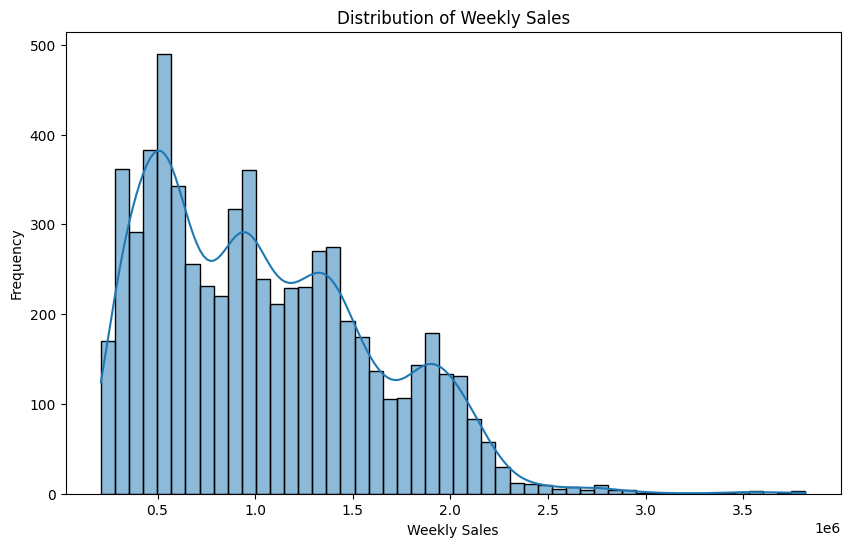

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(df["Weekly_Sales"], bins=50, kde=True)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

In [14]:
print(df["Weekly_Sales"].describe())

count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099862e+05
25%      5.533501e+05
50%      9.607460e+05
75%      1.420159e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64


<!-- Which stores generate the most sales? -->

Which stores have the most sales on average?

In [15]:
store_sales = ( df.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False))
print(store_sales)


Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
10    1.899425e+06
27    1.775216e+06
6     1.564728e+06
1     1.555264e+06
39    1.450668e+06
19    1.444999e+06
31    1.395901e+06
23    1.389864e+06
24    1.356755e+06
11    1.356383e+06
28    1.323522e+06
41    1.268125e+06
32    1.166568e+06
18    1.084718e+06
22    1.028501e+06
12    1.009002e+06
26    1.002912e+06
34    9.667816e+05
40    9.641280e+05
35    9.197250e+05
8     9.087495e+05
17    8.935814e+05
45    7.859814e+05
21    7.560691e+05
25    7.067215e+05
43    6.333247e+05
15    6.233125e+05
7     5.706173e+05
42    5.564039e+05
9     5.439806e+05
29    5.394514e+05
16    5.192477e+05
37    5.189003e+05
30    4.385796e+05
3     4.027044e+05
38    3.857317e+05
36    3.735120e+05
5     3.180118e+05
44    3.027489e+05
33    2.598617e+05
Name: Weekly_Sales, dtype: float64


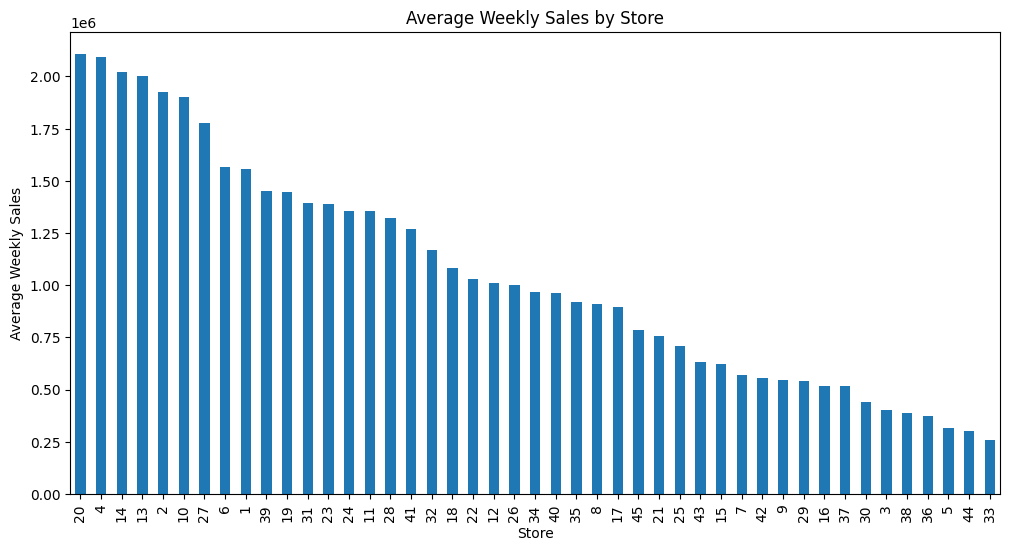

In [16]:
plt.figure(figsize=(12, 6))

store_sales.plot(kind="bar")

plt.title("Average Weekly Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.xticks(rotation=90)
plt.show()

- stores 20 &  4 generate the most sales consistently, while stores 5,44, and 33 are well behind

How do holidays impact sales?

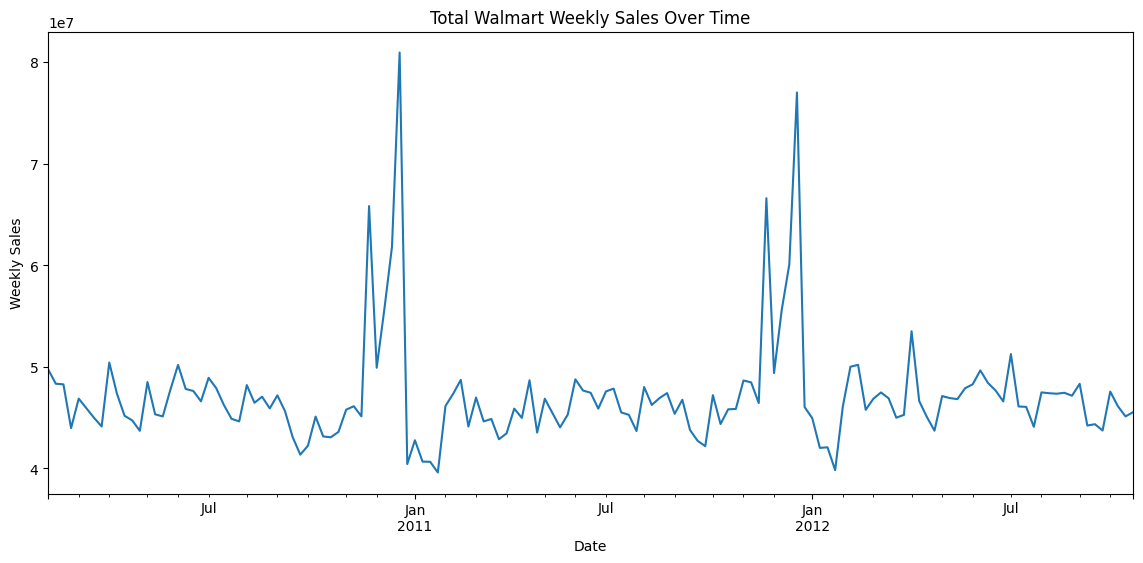

In [17]:
weekly_sales = (
    df.groupby("Date")["Weekly_Sales"]
      .sum()
      .sort_index()
)

plt.figure(figsize=(14, 6))

weekly_sales.plot()

plt.title("Total Walmart Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

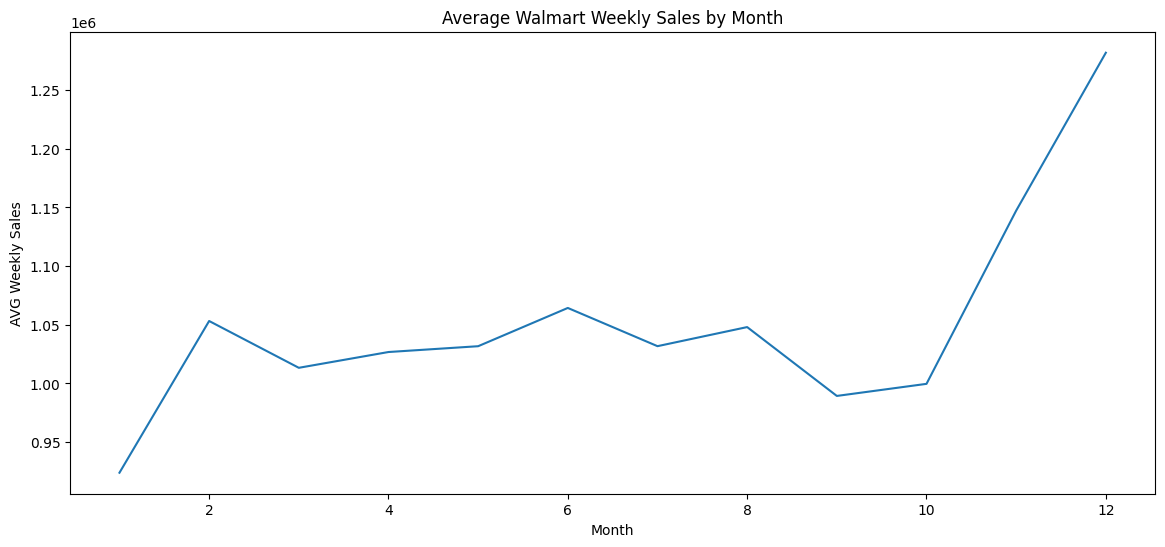

In [18]:
weekly_sales = (
    df.groupby("Month")["Weekly_Sales"]
      .mean()
)

plt.figure(figsize=(14, 6))

weekly_sales.plot()

plt.title("Average Walmart Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("AVG Weekly Sales")
plt.show()

- predictable pattern of sales with spikes corresponding to black friday and the christmas season followed by a valley in january/february

* investigate holiday tags

In [19]:
holiday_sales = (df.groupby("Holiday_Flag")["Weekly_Sales"].mean())
print(holiday_sales)

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


In [20]:
df["Holiday"] = df["Holiday_Flag"].map({
    0: "Non-Holiday",
    1: "Holiday"
})

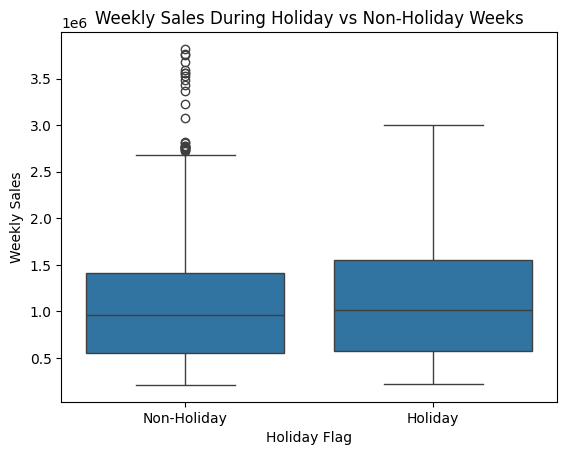

In [21]:
sns.boxplot(
    data=df,
    x="Holiday",
    y="Weekly_Sales"
)

plt.title("Weekly Sales During Holiday vs Non-Holiday Weeks")
plt.xlabel("Holiday Flag")
plt.ylabel("Weekly Sales")
plt.show()

In [22]:
Q1 = df.groupby("Holiday_Flag")["Weekly_Sales"].transform(
    lambda x: x.quantile(0.25)
)

Q3 = df.groupby("Holiday_Flag")["Weekly_Sales"].transform(
    lambda x: x.quantile(0.75)
)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["Outlier"] = (
    (df["Weekly_Sales"] < lower_bound) |
    (df["Weekly_Sales"] > upper_bound)
)

In [23]:
print(df["Outlier"].value_counts())

Outlier
False    6410
True       25
Name: count, dtype: int64


In [24]:
outliers = df[df["Outlier"]].sort_values(
    "Weekly_Sales",
    ascending=False
)

print(
    outliers[
        [
            "Store",
            "Date",
            "Weekly_Sales",
            "Holiday_Flag",
            "Temperature",
            "Fuel_Price",
            "CPI",
            "Unemployment"
        ]
    ]
)

      Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
1905     14 2010-12-24    3818686.45             0        30.59       3.141   
2763     20 2010-12-24    3766687.43             0        25.17       3.141   
1333     10 2010-12-24    3749057.69             0        57.06       3.236   
527       4 2011-12-23    3676388.98             0        35.92       3.103   
1762     13 2010-12-24    3595903.20             0        34.90       2.846   
1814     13 2011-12-23    3556766.03             0        24.76       3.186   
2815     20 2011-12-23    3555371.03             0        40.19       3.389   
475       4 2010-12-24    3526713.39             0        43.21       2.887   
1385     10 2011-12-23    3487986.89             0        48.36       3.541   
189       2 2010-12-24    3436007.68             0        49.97       2.886   
1957     14 2011-12-23    3369068.99             0        42.27       3.389   
241       2 2011-12-23    3224369.80             0  

- most the outliers were the days leading up to christmas

How do changing gas prices?

Temperature?

Unemployment?

In [25]:
numeric_cols = [
    "Weekly_Sales",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment"
]

print(df[numeric_cols].corr())

              Weekly_Sales  Temperature  Fuel_Price       CPI  Unemployment
Weekly_Sales      1.000000    -0.063810    0.009464 -0.072634     -0.106176
Temperature      -0.063810     1.000000    0.144982  0.176888      0.101158
Fuel_Price        0.009464     0.144982    1.000000 -0.170642     -0.034684
CPI              -0.072634     0.176888   -0.170642  1.000000     -0.302020
Unemployment     -0.106176     0.101158   -0.034684 -0.302020      1.000000


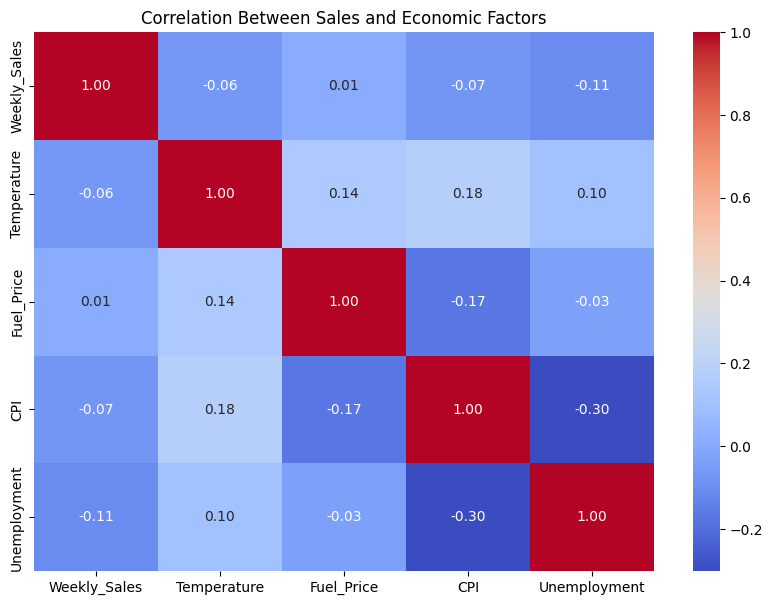

In [26]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Sales and Economic Factors")
plt.show()

- on first observation Unemployment has the greatest impact on sales, while fuel_prices might not have much of an impact

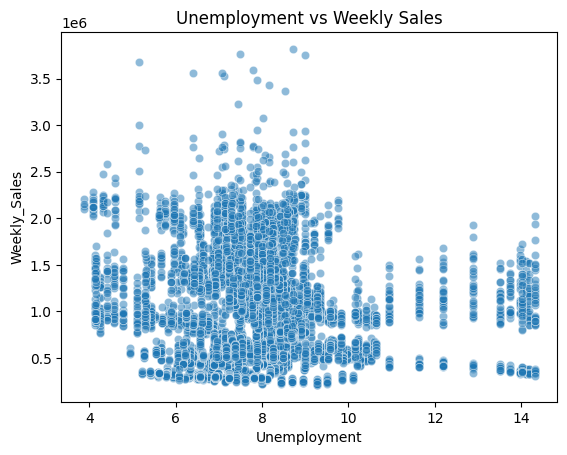

In [27]:
sns.scatterplot(
    data=df,
    x="Unemployment",
    y="Weekly_Sales",
    alpha=0.5
)

plt.title("Unemployment vs Weekly Sales")
plt.show()

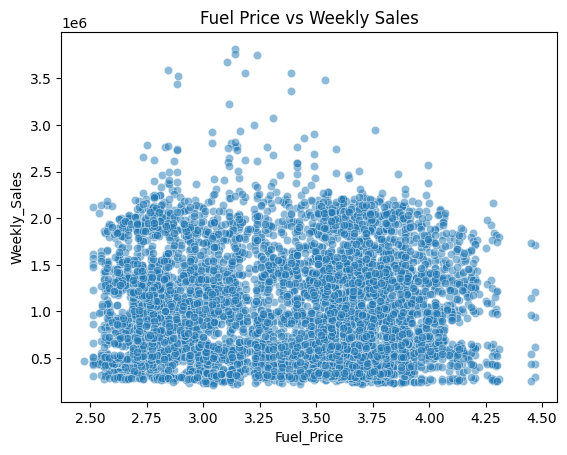

In [28]:
sns.scatterplot(
    data=df,
    x="Fuel_Price",
    y="Weekly_Sales",
    alpha=0.5
)

plt.title("Fuel Price vs Weekly Sales")
plt.show()

- gas prices seem to need to rise greatly to detract from store sales

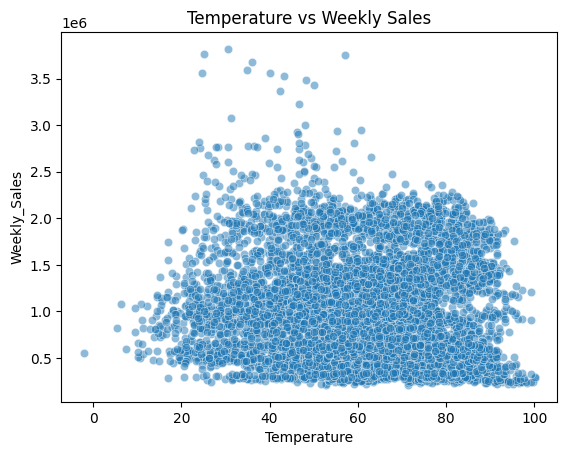

In [29]:
sns.scatterplot(
    data=df,
    x="Temperature",
    y="Weekly_Sales",
    alpha=0.5
)

plt.title("Temperature vs Weekly Sales")
plt.show()

* i wonder how much of this relation can be explained by seasonal trends. This may be a case of correlation over causation

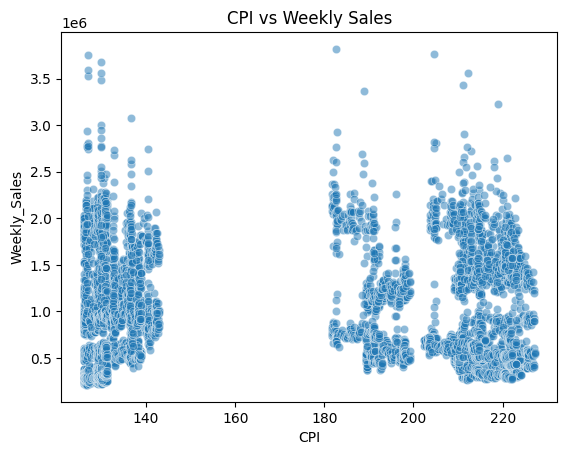

In [30]:
sns.scatterplot(
    data=df,
    x="CPI",
    y="Weekly_Sales",
    alpha=0.5
)

plt.title("CPI vs Weekly Sales")
plt.show()

lets look at each stores sales

In [31]:
store_summary = df.groupby("Store").agg(
    Average_Sales=("Weekly_Sales", "mean"),
    Median_Sales=("Weekly_Sales", "median"),
    Max_Sales=("Weekly_Sales", "max"),
    Min_Sales=("Weekly_Sales", "min")
)

In [32]:
print(store_summary.sort_values(
    "Average_Sales",
    ascending=False
).head(10))

       Average_Sales  Median_Sales   Max_Sales   Min_Sales
Store                                                     
20      2.107677e+06    2053165.41  3766687.43  1761016.51
4       2.094713e+06    2073951.38  3676388.98  1762539.30
14      2.020978e+06    2004330.30  3818686.45  1479514.66
13      2.003620e+06    1958823.56  3595903.20  1633663.12
2       1.925751e+06    1879107.31  3436007.68  1650394.44
10      1.899425e+06    1827521.71  3749057.69  1627707.31
27      1.775216e+06    1731935.43  3078162.08  1263534.86
6       1.564728e+06    1524390.07  2727575.18  1261253.18
1       1.555264e+06    1534849.64  2387950.20  1316899.31
39      1.450668e+06    1416005.59  2554482.84  1158698.44


In [33]:
store_summary["Sales_Std"] = (
    df.groupby("Store")["Weekly_Sales"].std()
)

print(
    store_summary.sort_values(
        "Sales_Std",
        ascending=False
    ).head(10)
)

       Average_Sales  Median_Sales   Max_Sales   Min_Sales      Sales_Std
Store                                                                    
14      2.020978e+06    2004330.30  3818686.45  1479514.66  317569.949476
10      1.899425e+06    1827521.71  3749057.69  1627707.31  302262.062504
20      2.107677e+06    2053165.41  3766687.43  1761016.51  275900.562742
4       2.094713e+06    2073951.38  3676388.98  1762539.30  266201.442297
13      2.003620e+06    1958823.56  3595903.20  1633663.12  265506.995776
23      1.389864e+06    1358444.07  2734277.10  1016756.10  249788.038068
27      1.775216e+06    1731935.43  3078162.08  1263534.86  239930.135688
2       1.925751e+06    1879107.31  3436007.68  1650394.44  237683.694682
39      1.450668e+06    1416005.59  2554482.84  1158698.44  217466.454833
6       1.564728e+06    1524390.07  2727575.18  1261253.18  212525.855862


In [34]:
store_summary["Sales_Std"] = (
    df.groupby("Store")["Weekly_Sales"].std()
)

print(
    store_summary.sort_values(
        "Sales_Std",
        ascending=True
    ).head(10)
)

       Average_Sales  Median_Sales  Max_Sales  Min_Sales     Sales_Std
Store                                                                 
37     518900.281958     518124.16  605791.46  451327.61  21837.461190
30     438579.616224     438068.71  519354.88  369722.32  22809.665590
33     259861.692028     258427.39  331173.51  209986.25  24132.927322
44     302748.866014     298080.45  376233.89  241937.11  24762.832015
5      318011.810490     310338.17  507900.07  260636.71  37737.965745
43     633324.723147     634815.10  725043.04  505405.85  40598.413260
38     385731.653287     380870.09  499267.66  303908.81  42768.169450
3      402704.441049     395107.35  605990.41  339597.38  46319.631557
42     556403.863147     556046.12  674919.45  428953.60  50262.925530
36     373511.992797     373267.58  489372.02  270677.98  60725.173579


* store 14 is far and away the most volatile store while 37 and 30 are the most consistent. 
- It would appear that the stores that average the fewest sales are less prone to great highs and lows
- even on its worst day, store 14 still easily earns double store 37s sales on its best day

Predict Weekly Sales Using:
- Store
- Holiday_flag
- Temperature
- Fuel Price
- CPI
- Unemployment
- time of year

** Linear regression

In [35]:
from sklearn.linear_model import LinearRegression

In [36]:
train = df[df["Date"] < "2012-01-01"]
test = df[df["Date"] >= "2012-01-01"]

X_train = train[["Store", "Year", "Month", "Week", "Holiday_Flag", "Unemployment", "Day_of_Year"]]
y_train = train["Weekly_Sales"]

X_test = test[["Store", "Year", "Month", "Week", "Holiday_Flag", "Unemployment", "Day_of_Year"]]
y_test = test["Weekly_Sales"]

lr = LinearRegression()
lr.fit(X_train, y_train)

print("R²:", lr.score(X_test, y_test))

R²: 0.11657675939454026


In [37]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr.coef_
})

print(coefficients)

        Feature   Coefficient
0         Store -14355.789162
1          Year  -9816.064409
2         Month  33291.993429
3          Week  -1456.682373
4  Holiday_Flag  59159.625913
5  Unemployment -10747.077259
6   Day_of_Year   -380.712199


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

predictions = lr.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("R²:", lr.score(X_test, y_test))
print("MAE:", mae)
print("RMSE:", rmse)

R²: 0.11657675939454026
MAE: 420682.11939852085
RMSE: 504273.4355455285


* This linear regression model only explains 11% of the variation

# Random Forest

In [39]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,r2_score

Store-level differences were the dominant predictor of weekly sales, accounting for 67.1% of Random Forest feature importance. Removing Store from the model reduced test-set R² from 95.6% to 11.7%, demonstrating that economic and seasonal variables alone explain relatively little of the substantial variation in sales across Walmart locations.

Holiday Flag does not fully account for the shopping season leading up to said holiday. 

In [54]:
df = df.sort_values("Date").copy()

holiday_dates = df.loc[
    df["Holiday_Flag"] == 1,
    "Date"
].unique()

df["holiday_leadup"] = df["Date"].apply(
    lambda date: int(
        any(
            (holiday_date > date) and
            ((holiday_date - date).days <= 7)
            for holiday_date in holiday_dates
        )
    )
)

New feature holiday_leadup accounts for the shopping days leading up to a holiday

In [55]:
print(
    df[["Date", "Holiday_Flag", "holiday_leadup"]]
    .sort_values("Date")
    .head(20)
)

           Date  Holiday_Flag  holiday_leadup
0    2010-02-05             0               1
429  2010-02-05             0               1
4290 2010-02-05             0               1
2145 2010-02-05             0               1
1430 2010-02-05             0               1
5005 2010-02-05             0               1
5863 2010-02-05             0               1
572  2010-02-05             0               1
6006 2010-02-05             0               1
3861 2010-02-05             0               1
715  2010-02-05             0               1
4576 2010-02-05             0               1
6149 2010-02-05             0               1
2431 2010-02-05             0               1
286  2010-02-05             0               1
1573 2010-02-05             0               1
4004 2010-02-05             0               1
5577 2010-02-05             0               1
858  2010-02-05             0               1
1859 2010-02-05             0               1


In [61]:
features = [
    "Store",
    
    "holiday_leadup",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    
    "Day_of_Year"
]

In [62]:
train = df[df["Date"] < "2012-04-01"]
test = df[df["Date"] >= "2012-04-01"]

X_train = train[features]
y_train = train["Weekly_Sales"]

X_test = test[features]
y_test = test["Weekly_Sales"]

In [63]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=20
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [64]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 120739.46045340737
RMSE: 248656.5955137441
R²: 0.7864394309477997


In [65]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

          Feature  Importance
0           Store    0.613307
4             CPI    0.166781
5    Unemployment    0.127612
6     Day_of_Year    0.056482
1  holiday_leadup    0.014292
3      Fuel_Price    0.011257
2     Temperature    0.010268
